# Прогнозирование оттока клиентов стримингового сервиса
Анализ и предсказание оттока (churn) на данных о 5000 подписчиков: какие поведенческие сигналы предсказывают уход, какие тарифы и способы оплаты рискованнее и какие факторы удерживают клиента.

**Данные:** `netflix_customer_churn.csv` — 5000 клиентов, 14 признаков (вовлечённость, тариф, оплата, демография), целевая переменная `churned`.

**Что делаю:** EDA по бизнес-вопросам · подготовка данных · две модели классификации (Logistic Regression и Random Forest) · извлечение драйверов оттока · бизнес-выводы.


## 0. Импорты и оформление графиков

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25,
    "axes.titlesize": 13, "axes.titleweight": "bold",
})
PALETTE = ["#1f3a5f", "#c96f4a", "#6a8d73", "#b0a08f"]

## 1. Загрузка данных

In [4]:
df = pd.read_csv("/content/netflix_customer_churn (2).csv")
print("строк:", len(df), "| колонок:", df.shape[1])
print("пропусков:", df.isna().sum().sum())
print("доля оттока:", round(df["churned"].mean(), 3))
df.head()

строк: 5000 | колонок: 14
пропусков: 0
доля оттока: 0.503


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


## 2. EDA: от чего зависит отток
Считаю долю оттока в разрезах. Приём: `churned` состоит из 0/1, поэтому **среднее по группе = доля оттока**.

In [5]:
bins = [18, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

sub_churn     = df.groupby("subscription_type")["churned"].mean().sort_values(ascending=False)
payment_churn = df.groupby("payment_method")["churned"].mean().sort_values(ascending=False)
region_churn  = df.groupby("region")["churned"].mean()
age_churn     = df.groupby("age_group", observed=True)["churned"].mean()

print("Отток по тарифу:\n", (sub_churn*100).round(1), "\n")
print("Отток по способу оплаты:\n", (payment_churn*100).round(1))

Отток по тарифу:
 subscription_type
Basic       61.8
Standard    45.4
Premium     43.7
Name: churned, dtype: float64 

Отток по способу оплаты:
 payment_method
Crypto         59.7
Gift Card      57.8
PayPal         47.1
Debit Card     43.7
Credit Card    43.6
Name: churned, dtype: float64


### Сильные сигналы: тариф и способ оплаты

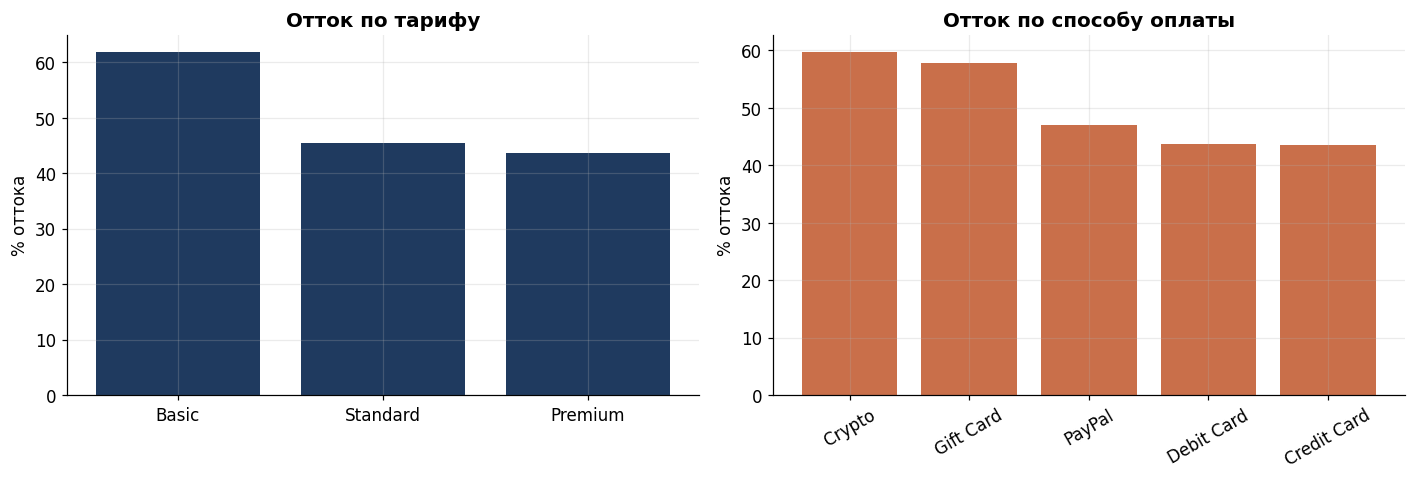

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(sub_churn.index, sub_churn.values*100, color=PALETTE[0])
ax[0].set_title("Отток по тарифу"); ax[0].set_ylabel("% оттока")
ax[1].bar(payment_churn.index, payment_churn.values*100, color=PALETTE[1])
ax[1].set_title("Отток по способу оплаты"); ax[1].set_ylabel("% оттока")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Что видно:** Basic уходит в 61,8% против 43,7% у Premium — дешёвый тариф удерживает хуже. По оплате: Crypto (59,7%) и Gift Card (57,8%) уходят заметно чаще, чем карты (~43,6%).

Регион и возраст — **шум**: разброс всего 3–6 пунктов без закономерности. география и демография отток не определяют.

In [7]:
print("Отток по региону (%):\n", (region_churn*100).round(1), "\n")
print("Отток по возрасту (%):\n", (age_churn*100).round(1))

Отток по региону (%):
 region
Africa           48.3
Asia             50.7
Europe           51.7
North America    49.5
Oceania          50.1
South America    51.4
Name: churned, dtype: float64 

Отток по возрасту (%):
 age_group
18-25    49.6
26-35    50.4
36-45    48.1
46-55    54.5
56+      48.7
Name: churned, dtype: float64


## 3. Подготовка данных для модели
Категории → числа через one-hot (`get_dummies`), затем разделение на признаки `X` и ответ `y`, train/test split и масштабирование.

In [8]:
df_encoded = pd.get_dummies(
    df.drop(columns=["age_group"]),
    columns=["subscription_type", "payment_method", "region", "device", "gender", "favorite_genre"]
)
y = df_encoded["churned"]
X = df_encoded.drop(columns=["churned", "customer_id"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit только на train
X_test_scaled  = scaler.transform(X_test)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (3750, 35) | test: (1250, 35)


## 4. Модель 1 — Logistic Regression
Базовая линейная модель. Данные масштабированы.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print("accuracy (logreg):", round(acc_lr, 3))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=["остался", "ушёл"], digits=3))

accuracy (logreg): 0.886
[[546  75]
 [ 67 562]]
              precision    recall  f1-score   support

     остался      0.891     0.879     0.885       621
        ушёл      0.882     0.893     0.888       629

    accuracy                          0.886      1250
   macro avg      0.886     0.886     0.886      1250
weighted avg      0.886     0.886     0.886      1250



## 5. Модель 2 — Random Forest
Ансамбль деревьев ловит нелинейные связи. Деревьям масштабирование не нужно т.к работают с немасштабированными данными.

In [10]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators=200, random_state=42)
forest.fit(X_train, y_train)
y_pred_rf = forest.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("accuracy (forest):", round(acc_rf, 3))
print(classification_report(y_test, y_pred_rf, target_names=["остался", "ушёл"], digits=3))

accuracy (forest): 0.978
              precision    recall  f1-score   support

     остался      0.973     0.982     0.978       621
        ушёл      0.982     0.973     0.978       629

    accuracy                          0.978      1250
   macro avg      0.978     0.978     0.978      1250
weighted avg      0.978     0.978     0.978      1250



### Сравнение моделей

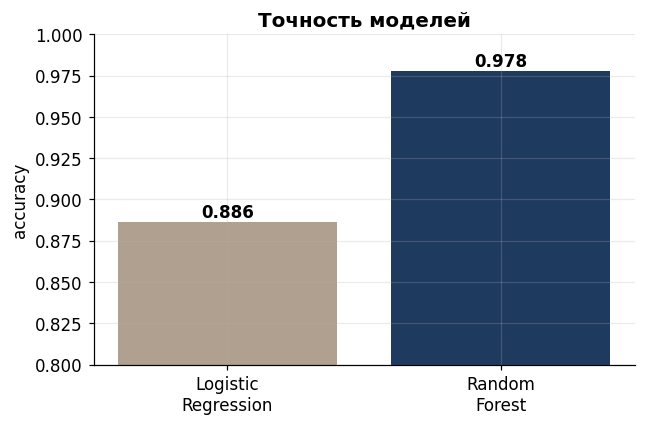

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(["Logistic\nRegression", "Random\nForest"], [acc_lr, acc_rf], color=[PALETTE[3], PALETTE[0]])
plt.ylim(0.8, 1.0); plt.ylabel("accuracy"); plt.title("Точность моделей")
for i, v in enumerate([acc_lr, acc_rf]):
    plt.text(i, v+0.003, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

Random Forest заметно точнее (≈0.98 против ≈0.89): значит связи в данных **нелинейные** и отток запускается комбинацией условий, которую линейная модель не улавливает.

## 6. Драйверы оттока
Что именно гонит отток. Проверяю двумя независимыми методами: коэффициенты логрега и важность признаков леса.

In [12]:
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print("Логрег — снижают отток:\n", coef.head(5).round(3))
print("\nЛогрег — повышают отток:\n", coef.tail(5).round(3))

Логрег — снижают отток:
 avg_watch_time_per_day      -4.721
watch_hours                 -3.755
number_of_profiles          -1.108
monthly_fee                 -0.360
payment_method_Debit Card   -0.330
dtype: float64

Логрег — повышают отток:
 favorite_genre_Drama        0.144
payment_method_Gift Card    0.365
payment_method_Crypto       0.439
subscription_type_Basic     0.454
last_login_days             2.357
dtype: float64


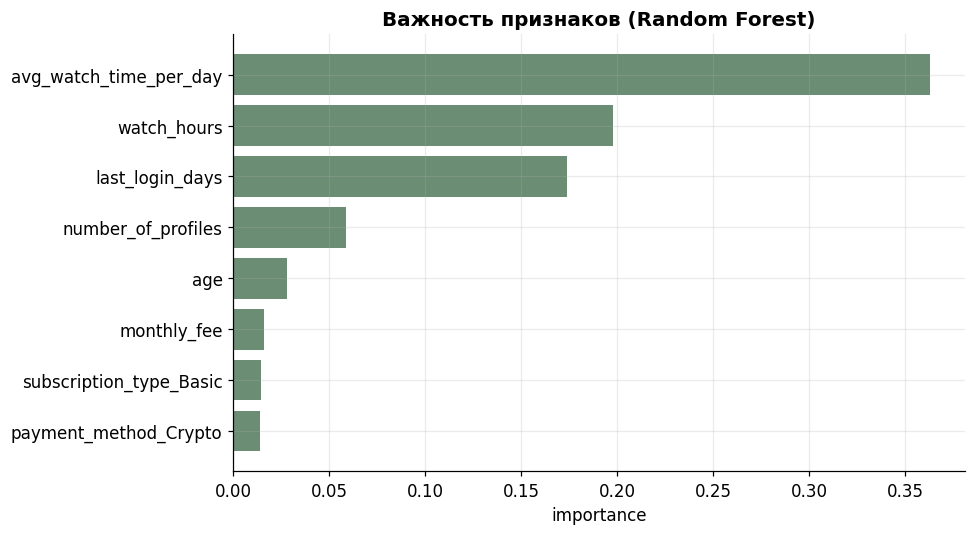

,0
avg_watch_time_per_day,0.363
watch_hours,0.198
last_login_days,0.174
number_of_profiles,0.059
age,0.028
monthly_fee,0.016
subscription_type_Basic,0.015
payment_method_Crypto,0.014


In [13]:
imp = pd.Series(forest.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
plt.figure(figsize=(9, 5))
plt.barh(imp.index[::-1], imp.values[::-1], color=PALETTE[2])
plt.title("Важность признаков (Random Forest)"); plt.xlabel("importance")
plt.tight_layout(); plt.show()
imp.round(3)

## 7. Выводы

Отток определяется вовлечённостью, а не демографией.** Три независимых метода (ручной EDA, коэффициенты логрега, важность признаков леса) сошлись на одном: сильнее всего отток предсказывают **время просмотра** (`avg_watch_time_per_day`, `watch_hours`) и **давность последнего входа** (`last_login_days`). Падение просмотров и рост дней без входа это самые ранние индикаторы ухода.

**По бизнес-вопросам:**
1. *Ранние индикаторы:* поведенческие метрики вовлечённости являются главным сигналом, за ними нужно следить, чтобы ловить отток заранее.
2. *Тарифы:* Basic уходит сильнее всего (61,8%), Premium удерживает лучше (43,7%).
3. *Регион и демография:* значимых различий нет , это не точка приложения усилий.
4. *Оплата:* Crypto и Gift Card дают отток на ~15 п.п. выше, чем банковские карты , вероятно, из-за отсутствия привязки к автоплатежу.

**Модель:** Random Forest даёт accuracy ≈0.98 и recall по оттоку ≈0.97  практически не пропускает уходящих.



## Источник данных
- Датасет: Netflix Customer Churn (Kaggle), файл `netflix_customer_churn.csv`.
- Все расчёты и выводы - собственные.
